
# metabeta — getting started

**metabeta** fits Bayesian mixed-effects models in milliseconds instead of minutes.
It uses a pre-trained neural network to approximate the posterior — no MCMC, no warmup.

This notebook walks through the full workflow on the classic `sleepstudy` dataset:
**load → sample → interpret.**


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from metabeta.models.api import Api

mb = Api.from_pretrained('normal')

## 1. Dataset

The `sleepstudy` dataset (Belenky et al. 2003) tracks reaction times (ms) for 18 subjects
across 10 days of sleep restriction — a two-level design with observations nested within
subjects (which we treat as the grouping variable).

Visually the trajectories fan out: subjects differ not only in their baseline reaction time
but also in how quickly they deteriorate — motivating a **random slope** model.


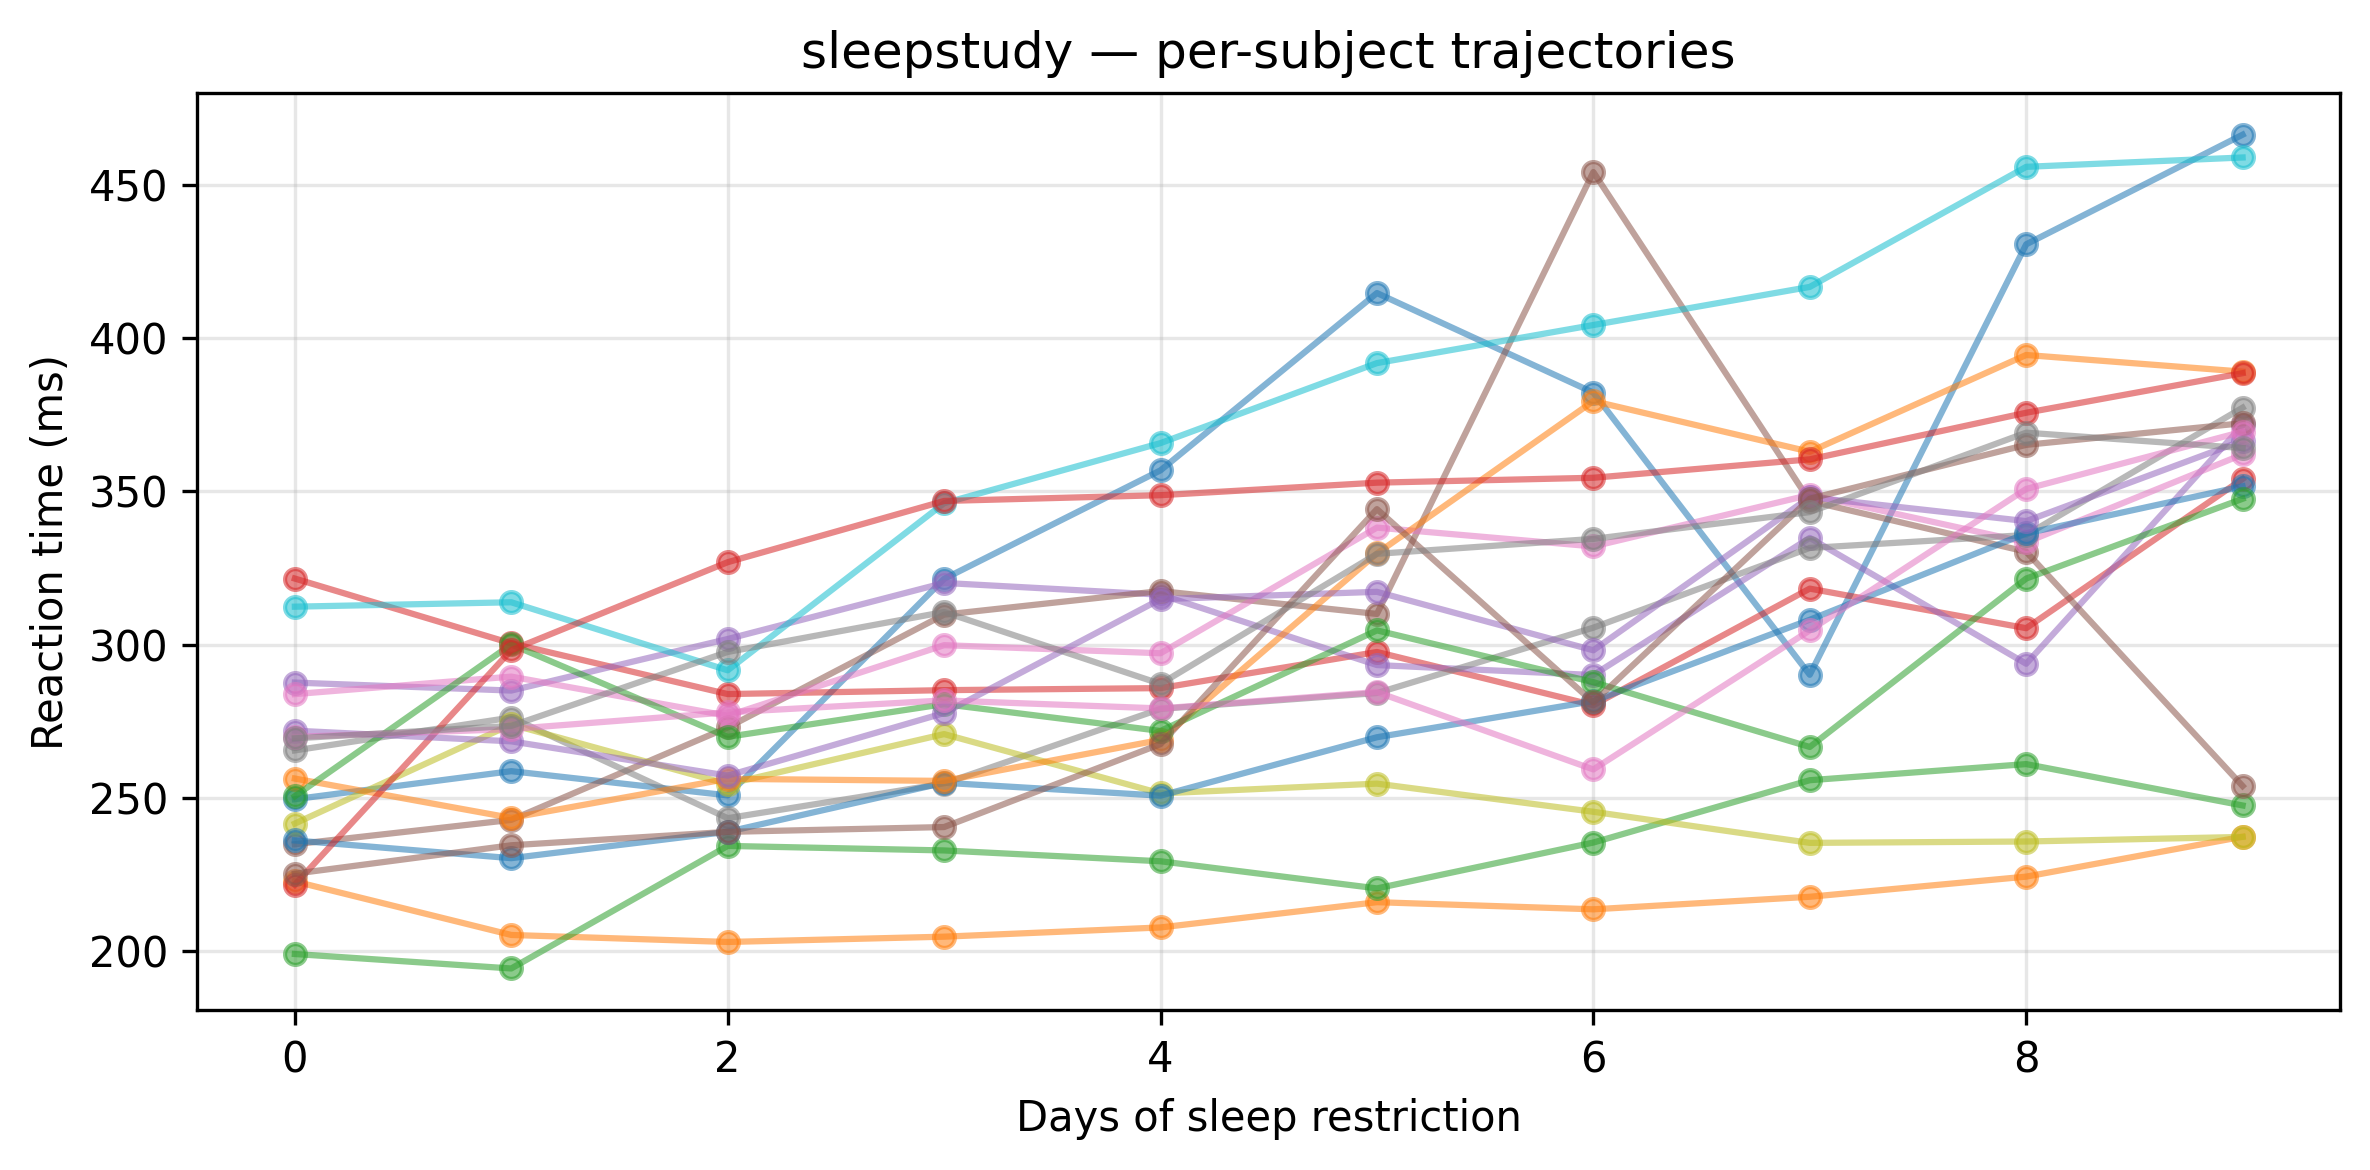

In [2]:
import statsmodels.api as sm

df = sm.datasets.get_rdataset('sleepstudy', 'lme4').data.rename(
    columns={'Reaction': 'y'}
)

fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
for _, grp in df.groupby('Subject'):
    ax.plot(grp['Days'], grp['y'], 'o-', alpha=0.55, lw=1.5, ms=5)
ax.set_xlabel('Days of sleep restriction')
ax.set_ylabel('Reaction time (ms)')
ax.set_title('sleepstudy — per-subject trajectories')
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## 2. Inference

Describe the model with a standard **lme4-style formula**: `Days` as a fixed slope,
each subject gets its own random intercept **and** random slope.
The intercept is implicit inside `(Days | group)` — equivalent to `(1 + Days | group)`.
`mb.sample()` handles preprocessing internally, routes to the right submodel, and
returns 1000 posterior draws in under a second.


In [3]:
%%time
result = mb.sample(
    df,
    formula='y ~ Days + (Days | Subject)',
    n_samples=1000,
    diagnostics=True, # enables posterior predictive evaluation 
)

CPU times: user 204 ms, sys: 18 ms, total: 222 ms
Wall time: 193 ms


## 3. Results

All estimates are on the **original scale** of the data (ms).

| Column | Meaning |
|--------|---------|
| Mean · SD · 2.5% · 97.5% | Posterior mean, SD, and 95% credible interval |
| P(>0) | Posterior probability the effect is positive |
| Contr. | Posterior contraction — 1 = fully data-driven, 0 = prior-dominated |

**Standard Deviations** shows σ_Intercept and σ_Days (between-subject spread) plus σ_Residual.
**Correlations** shows the posterior mean correlation between each subject's random intercept
and random slope deviation.

Fit metrics at the bottom: **R²** (variance explained), **LOO-NLL** (leave-one-out
predictive performance [[1]](#notes)), and **Pareto k** (LOO-NLL reliability; < 0.7 is fine).


In [4]:
print(mb.posteriorSummary(result, x_scale='original'))


Formula:  y ~ Days + (Days | Subject)
n = 180   m = 18
Priors:
  Intercept ~ N(298.5, 140.4)
  days ~ N(0, 48.89)
  σ_Intercept ~ HN(140.4)
  σ_days ~ HN(140.4)
  Corr ~ LKJ(1)
  σ_Residual ~ HT₅(56.17)

Fixed Effects:
|           |    Mean |    SD |    2.5% |   50.0% |   97.5% |   P(>0) |   Contr. |
|-----------|---------|-------|---------|---------|---------|---------|----------|
| Intercept | 250.470 | 8.929 | 231.930 | 250.628 | 267.787 |   1.000 |    0.996 |
| days      |  10.392 | 1.802 |   6.739 |  10.386 |  13.812 |   1.000 |    0.999 |

Standard Deviations:
|           |   Mean |    SD |   2.5% |   50.0% |   97.5% |
|-----------|--------|-------|--------|---------|---------|
| Intercept | 41.050 | 7.805 | 28.749 |  40.035 |  58.514 |
| days      | 18.658 | 4.366 | 11.686 |  18.045 |  28.407 |
| Residual  | 26.125 | 1.618 | 23.162 |  26.043 |  29.712 |

Correlations:
|           |   Intercept |   days |
|-----------|-------------|--------|
| Intercept |       1.000 |  0.659 |
|

### Per-subject random effects

Each subject deviates from the population in two ways: a random **intercept** shift (ms) and
a random **slope** shift (extra ms per day above the population trend).
**z** = posterior mean ÷ σ; |z| > 2 flags an unusual group.
**SD ratio** = empirical SD of group estimates ÷ posterior mean of σ [[2]](#notes).


In [5]:
print(mb.rfxSummary(result))


Random Effects:

Intercept:
|   Group |   n |    Mean |     SD |     2.5% |   50.0% |   97.5% |     z |
|---------|-----|---------|--------|----------|---------|---------|-------|
|     308 |  10 |  44.666 | 12.780 |   21.127 |  44.646 |  69.412 |  1.09 |
|     309 |  10 | -78.049 | 13.251 | -103.153 | -77.825 | -50.957 | -1.90 |
|     310 |  10 | -62.439 | 13.129 |  -88.146 | -61.953 | -35.664 | -1.52 |
|     330 |  10 |   3.857 | 12.621 |  -20.495 |   3.781 |  29.126 |  0.09 |
|     331 |  10 |  10.016 | 12.659 |  -14.741 |  10.590 |  33.099 |  0.24 |
|     332 |  10 |   9.059 | 12.248 |  -14.546 |   9.061 |  31.366 |  0.22 |
|     333 |  10 |  17.116 | 12.543 |   -7.031 |  16.847 |  41.181 |  0.42 |
|     334 |  10 |  -1.203 | 12.747 |  -27.876 |  -1.231 |  24.565 | -0.03 |
|     335 |  10 | -46.745 | 12.804 |  -71.889 | -46.739 | -21.567 | -1.14 |
|     337 |  10 |  75.130 | 13.120 |   49.907 |  75.341 | 101.883 |  1.83 |
|     349 |  10 | -18.982 | 13.066 |  -44.891 | -19.312 |   

## 4. Posterior distributions

The pair grid shows the joint posterior over all global parameters.

- **Diagonal** — sampled marginal posterior (green) with analytical prior (blue)
- **Upper triangle** — sampled posterior scatter
- **Lower triangle** — sampled posterior density contours (green) with analytical prior countours (blue)

With two random effects (random intercept + random slope), the grid includes σ_Intercept,
σ_Days, and their correlation.


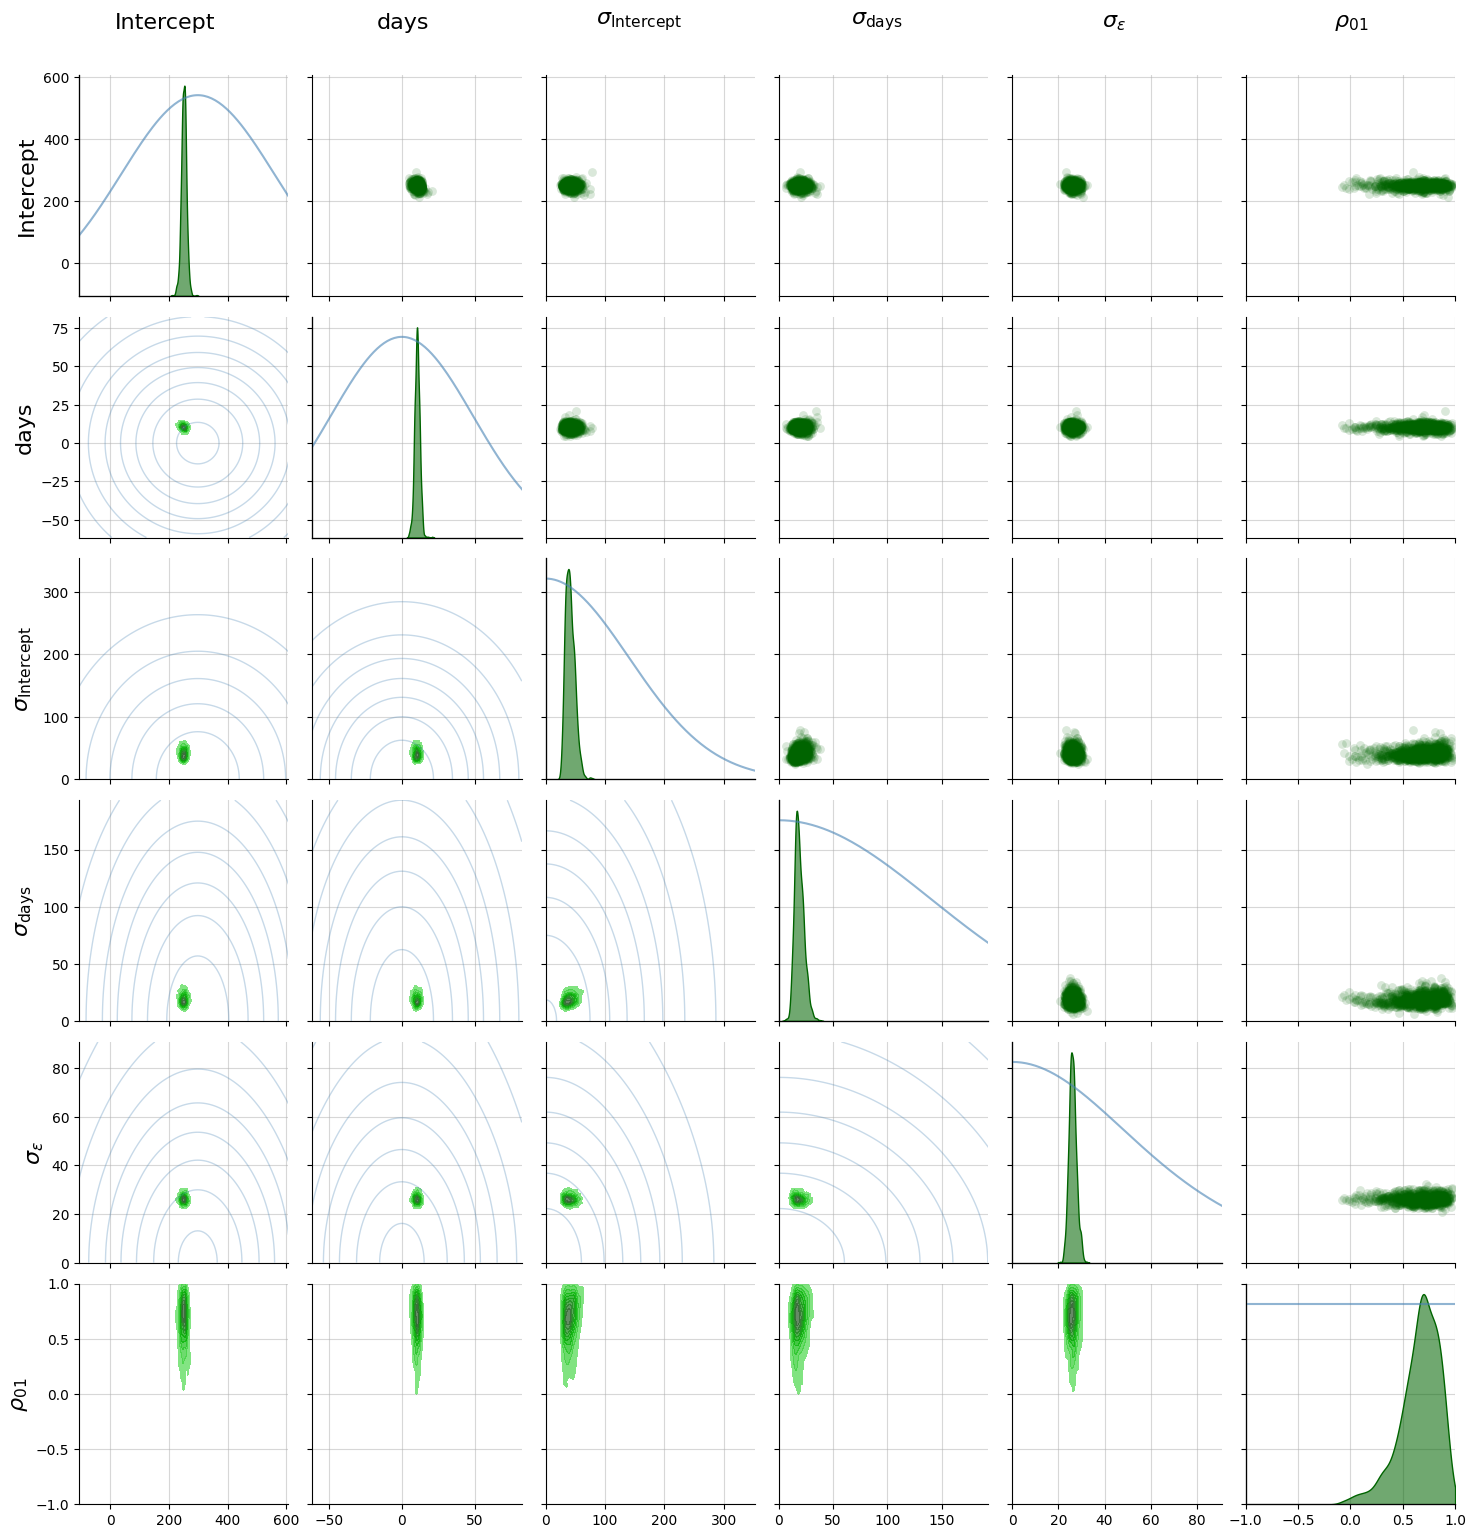

In [6]:
mb.plotParameters(result, with_prior=True, prior_xlim=True);
# set with_prior=False to only see the posterior
# alternatively set prior_xlim=False to keep prior but focus the axis limits on posterior

## 5. Model fit

Now back to the dataset. The random slope model fits group-specific offsets to **both** the
global intercept and the global slope: each subject has their own baseline reaction time *and*
their own rate of deterioration with sleep restriction.
The orange ribbon is the 95% credible interval for the population mean trajectory.


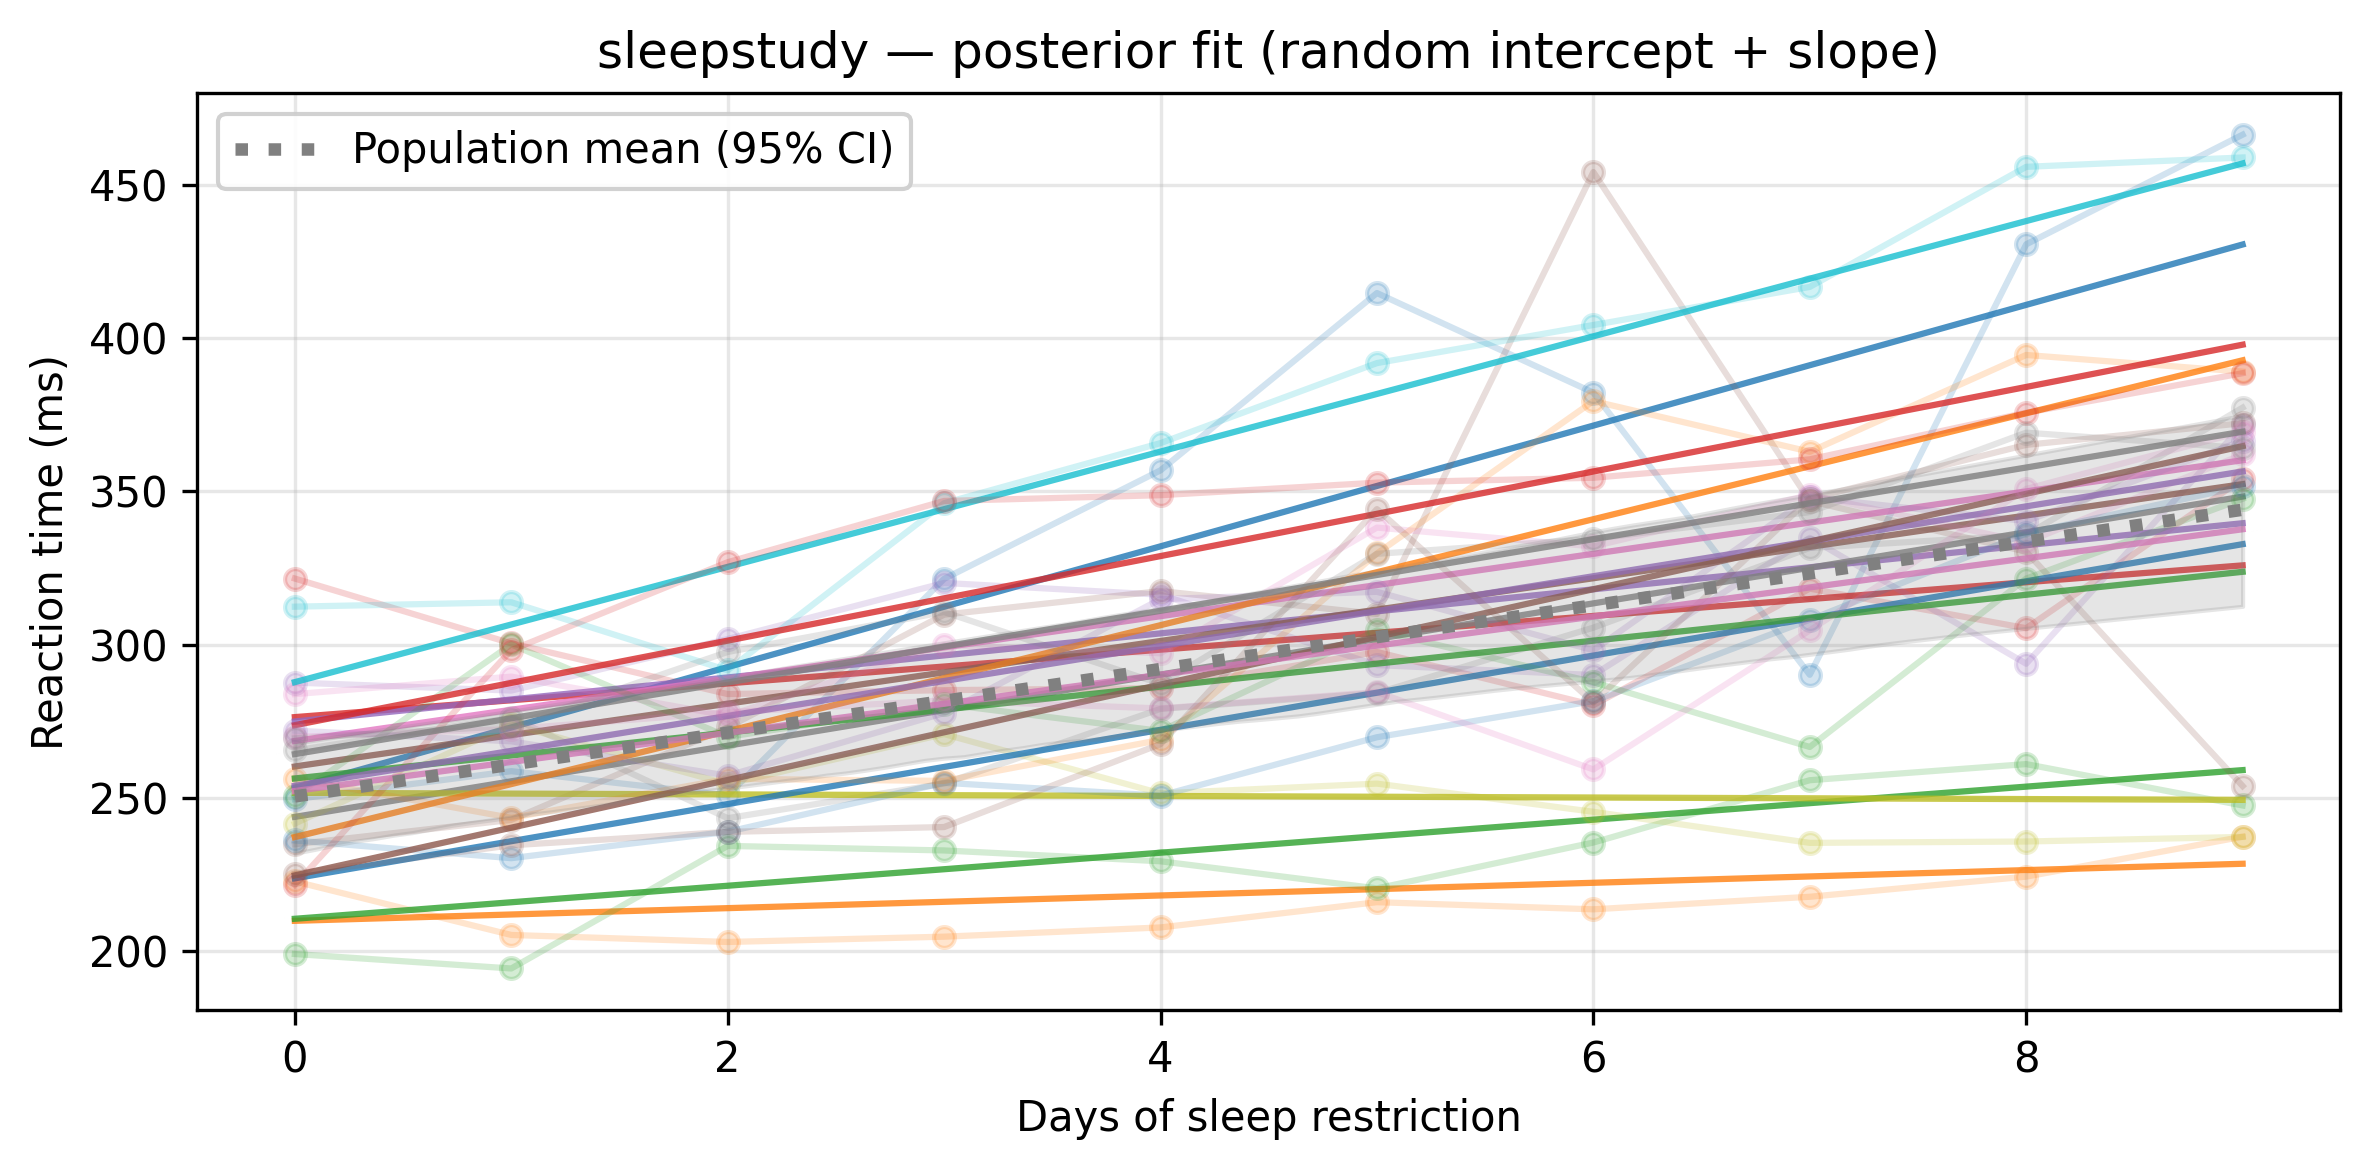

In [7]:
si = result.scale_info
ffx = si.to_original_scale(result.proposal.ffx[0]).numpy()  # (S, d)
rfx = result.proposal.rfx[0].numpy()                         # (m, S, q)
x_std_days = float(si.x_stds[1])    # SD of Days used for standardization
x_mean_days = float(si.x_means[1])  # mean of Days used for standardization
days = np.linspace(df["Days"].min(), df["Days"].max(), 100)

pop = ffx[:, 0:1] + ffx[:, 1:2] * days          # (S, 100)
pop_lo, pop_hi = np.percentile(pop, [2.5, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
for i, (_, grp) in enumerate(df.groupby("Subject")):  # sorted order matches rfx
    line, = ax.plot(grp["Days"], grp["y"], "o-", alpha=0.2, lw=1.5, ms=5)
    # group-specific slope and intercept (back-transformed from standardized rfx)
    slope_i = (ffx[:, 1] + rfx[i, :, 1] / x_std_days).mean()
    intercept_i = (ffx[:, 0] + rfx[i, :, 0] - rfx[i, :, 1] / x_std_days * x_mean_days).mean()
    ax.plot(days, intercept_i + slope_i * days,
            color=line.get_color(), lw=1.5, alpha=0.8)

ax.fill_between(days, pop_lo, pop_hi, color="grey", alpha=0.20, zorder=3)
ax.plot(days, np.mean(pop, axis=0), color="grey", lw=3.0, ls='dotted', zorder=4,
        label="Population mean (95% CI)")
ax.set_xlabel("Days of sleep restriction")
ax.set_ylabel("Reaction time (ms)")
ax.set_title("sleepstudy — posterior fit (random intercept + slope)")
ax.legend(framealpha=0.9)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


<a id="notes"></a>

---

**Notes**

1. LOO-NLL uses PSIS leave-one-out cross-validation ([Vehtari et al. 2017](https://link.springer.com/article/10.1007/s11222-016-9696-4)). It approximates the mean negative log likelihood of left-out Y under the posterior predictive distribution. Lower is better.
   Pareto k < 0.7 indicates reliable LOO estimates.

2. SD ratio compares the empirical SD of the RFX (over groups) with its posterior estimate. Values near 1 mean little shrinkage (many groups or large between-group variance relative to within-group noise). Values below 1 are expected: partial pooling shrinks group estimates toward zero, so their empirical SD underestimates
   the true σ.
